# MNL-Bandit: three algorithms, two problems

Implementation and partial replication of

> Agrawal, Avadhanula, Goyal & Zeevi (2019), *MNL-Bandit: A Dynamic Learning
> Approach to Assortment Selection*, **Operations Research** 67(5).

**Contents**

| section | what it does |
|---|---|
| 1 | two sanity checks on the implementation |
| 2 | the three algorithms compared |
| 3 | experiment 1 — synthetic instance, eq. (7.1), four values of $\varepsilon$ |
| 4 | how the UCI car data is turned into an MNL instance |
| 5 | experiment 2 — UCI cars, 1728 products |
| 6 | run the algorithms live (~2 min) |
| 7 | summary |

All code is in [`../code/algorithms.py`](../code/algorithms.py). Plots below load
precomputed results from `../results/` (41 min to generate); **section 6 runs the
real algorithms live** so the saved numbers can be checked.

Requires `numpy` and `matplotlib`.

In [1]:
import json
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make ../code importable whether you run this from the notebook folder or the
# project root.
for candidate in ["../code", "code", "github/code"]:
    if os.path.isdir(candidate):
        sys.path.insert(0, os.path.abspath(candidate))
        break

import algorithms

RESULTS_DIR = next(p for p in ["../results", "results", "github/results"]
                   if os.path.isdir(p))
with open(os.path.join(RESULTS_DIR, "experiment_results.json")) as fh:
    saved = json.load(fh)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

print("loaded saved results")
print("  settings:", saved["settings"])
print(f"  these took {saved['runtime_minutes']:.0f} minutes to compute")

loaded saved results
  settings: {'quick': False, 'epsilon_values': [0.05, 0.1, 0.15, 0.25], 'horizons_experiment_1': [2000, 5000, 10000, 25000, 50000, 100000], 'seeds_experiment_1': 10, 'horizons_experiment_2': [10000, 25000, 50000, 100000], 'seeds_experiment_2': 6}
  these took 41 minutes to compute


---

## 1. Setup check

Two quick checks that the implementation behaves as the model says it should,
before running anything larger.

**(a)** Adding products to an assortment reduces every other product's share,
through the shared denominator of eq. (2.1).

**(b)** The epoch estimator is unbiased for $v_i$ regardless of what else is on
offer — the property that makes the whole approach work.

**(a) The shared denominator.**


In [2]:
# Three products. The first is the most attractive.
v = np.array([0.8, 0.5, 0.3])
r = np.array([1.0, 1.0, 1.0])     # all worth the same revenue

sales_of_product_0 = []
for S in [(0,), (0, 1), (0, 1, 2)]:
    per_product, no_buy = algorithms.choice_probabilities(S, v)
    sales_of_product_0.append(per_product[0])
    names = ", ".join(f"product {i}" for i in S)
    print(f"showing {{{names}}}")
    print(f"    P(buy product 0) = {per_product[0]:.3f}"
          f"     P(buy nothing) = {no_buy:.3f}")

drop = " to ".join(f"{p:.3f}" for p in sales_of_product_0)
print()
print(f"Product 0 itself never changed, but its sales fell from {drop}")
print("simply because we displayed other things beside it.")

showing {product 0}
    P(buy product 0) = 0.444     P(buy nothing) = 0.556
showing {product 0, product 1}
    P(buy product 0) = 0.348     P(buy nothing) = 0.435
showing {product 0, product 1, product 2}
    P(buy product 0) = 0.308     P(buy nothing) = 0.385

Product 0 itself never changed, but its sales fell from 0.444 to 0.348 to 0.308
simply because we displayed other things beside it.


**(b) The epoch estimator.** Offer the same set until a customer buys
nothing, then count purchases. The shared denominator cancels in the ratio
$P(\text{buy } i)/P(\text{buy nothing}) = v_i$, so the count has mean
exactly $v_i$ whatever else is displayed.


In [3]:
rng = np.random.default_rng(0)

# The SAME product 0 (v = 0.8), measured inside two very different sets.
for S in [(0,), (0, 1, 2)]:
    counts = [algorithms.run_one_epoch(S, v, rng)[0].get(0, 0)
              for _ in range(20000)]
    print(f"showing {S}:  average purchases of product 0 per epoch"
          f" = {np.mean(counts):.4f}")

print(f"\ntrue v[0] = {v[0]}")
print("\nBoth estimates land on 0.8, even though the two sets give product 0")
print("very different per-customer sales rates. That is the cancellation.")

showing (0,):  average purchases of product 0 per epoch = 0.7888


showing (0, 1, 2):  average purchases of product 0 per epoch = 0.8044

true v[0] = 0.8

Both estimates land on 0.8, even though the two sets give product 0
very different per-customer sales rates. That is the cancellation.


---

## 2. The three algorithms

Implemented in [`../code/algorithms.py`](../code/algorithms.py); paper section
numbers given for reference.

| | source | difference | told in advance |
|---|---|---|---|
| **Algorithm 1** | paper §3.2 | optimistic estimate $\bar v_i + $ margin, eq. (3.4) | nothing |
| **Algorithm 3** | paper §6.2 | forced exploration + margin widened to $\max\{\sqrt{\bar v}, \bar v\}$ | nothing |
| **Sauré–Zeevi** | SZ (2013) Alg. 1 | explore $20\log T$ per group, then commit | exploration length |

---

## 3. Experiment 1 — a synthetic problem at four difficulty levels

**The instance** (equation 7.1 in the paper). Ten products, display at most
$K = 4$. Four products are slightly better than the other six:

$$v_i = 0.25 + \varepsilon \ \ \text{for products } 1, 2, 9, 10;
\qquad v_i = 0.25 \ \ \text{for the rest}$$

Every product earns the same revenue, so the task is purely **to identify which
four products are the good ones**.

$\varepsilon$ sets the difficulty. At $\varepsilon = 0.05$ the good and bad
products are nearly identical and telling them apart is hard; at
$\varepsilon = 0.25$ the difference is obvious.

In [4]:
for eps in [0.05, 0.25]:
    v_syn, r_syn, K_syn = algorithms.synthetic_instance(eps)
    best_value, best_set = algorithms.best_assortment(v_syn, r_syn, K_syn)

    # how much worse is the second-best set?
    others = []
    from itertools import combinations
    for S in combinations(range(10), 4):
        value = algorithms.expected_revenue(S, v_syn, r_syn)
        if set(S) != set(best_set):
            others.append(value)
    gap = best_value - max(others)

    print(f"epsilon = {eps}")
    print(f"    attractiveness values : {np.round(v_syn, 2)}")
    print(f"    best set to show      : products "
          f"{tuple(int(i) + 1 for i in best_set)}")
    print(f"    its revenue           : {best_value:.4f}")
    print(f"    gap to 2nd-best set   : {gap:.4f}"
          f"   <- this is what makes it easy or hard")
    print()

epsilon = 0.05
    attractiveness values : [0.3  0.3  0.25 0.25 0.25 0.25 0.25 0.25 0.3  0.3 ]
    best set to show      : products (1, 2, 9, 10)
    its revenue           : 0.5455
    gap to 2nd-best set   : 0.0106   <- this is what makes it easy or hard

epsilon = 0.25
    attractiveness values : [0.5  0.5  0.25 0.25 0.25 0.25 0.25 0.25 0.5  0.5 ]
    best set to show      : products (1, 2, 9, 10)
    its revenue           : 0.6667
    gap to 2nd-best set   : 0.0303   <- this is what makes it easy or hard



In [5]:
exp1 = saved["experiment_1"]
eps_list = sorted(exp1, key=float)
algo_names = ["Algorithm 1", "Algorithm 3", "Saure-Zeevi"]

print("FINAL REGRET after 100,000 customers   (average over 10 runs)")
print("=" * 66)
print(f"{'difficulty':>12} | " + " | ".join(f"{a:>13}" for a in algo_names))
print("-" * 66)
for key in eps_list:
    row = f"{'eps = ' + key:>12} | "
    cells = []
    for a in algo_names:
        last = exp1[key]["results"][a][-1]
        cells.append(f"{last['mean']:8.1f} +-{last['std_error']:4.1f}")
    print(row + " | ".join(cells))

print()
print("Reading this: lower is better. Note how Saure-Zeevi improves")
print("dramatically as the problem gets easier (left to right), while the")
print("other two stay roughly flat.")

FINAL REGRET after 100,000 customers   (average over 10 runs)
  difficulty |   Algorithm 1 |   Algorithm 3 |   Saure-Zeevi
------------------------------------------------------------------
  eps = 0.05 |   1440.8 +-16.1 |   1509.9 +-20.9 |   1764.5 +-179.6
   eps = 0.1 |   1506.7 +-16.7 |   1599.3 +-11.8 |   1343.3 +-395.2
  eps = 0.15 |   1361.3 +-12.5 |   1443.4 +- 9.0 |    779.3 +-357.2
  eps = 0.25 |   1091.8 +- 9.0 |   1170.5 +- 8.4 |     92.4 +- 0.0

Reading this: lower is better. Note how Saure-Zeevi improves
dramatically as the problem gets easier (left to right), while the
other two stay roughly flat.


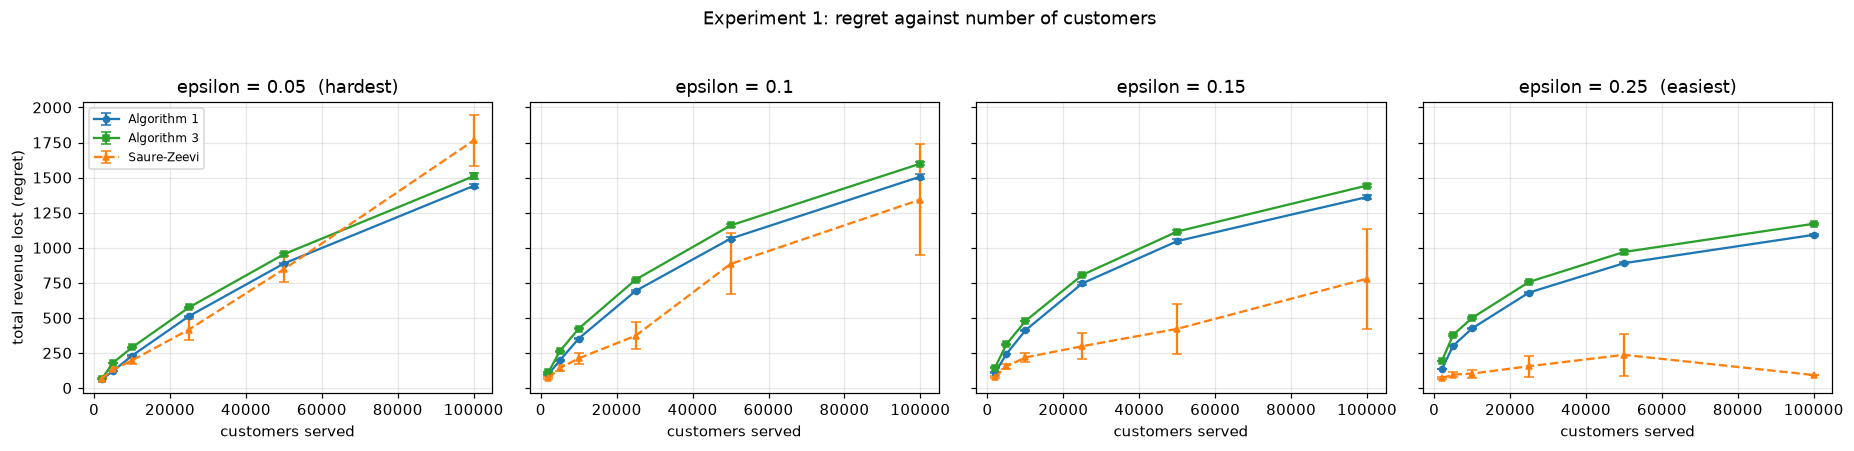

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9), sharey=True)
colours = {"Algorithm 1": "tab:blue", "Algorithm 3": "tab:green",
           "Saure-Zeevi": "tab:orange"}
styles = {"Algorithm 1": "o-", "Algorithm 3": "s-", "Saure-Zeevi": "^--"}

for ax, key in zip(axes, eps_list):
    for a in algo_names:
        rows = exp1[key]["results"][a]
        T = [row["T"] for row in rows]
        mean = [row["mean"] for row in rows]
        err = [row["std_error"] for row in rows]
        ax.errorbar(T, mean, yerr=err, fmt=styles[a], color=colours[a],
                    capsize=3, markersize=4, label=a)
    ax.set_title(f"epsilon = {key}" +
                 ("  (hardest)" if key == eps_list[0] else
                  "  (easiest)" if key == eps_list[-1] else ""))
    ax.set_xlabel("customers served")
axes[0].set_ylabel("total revenue lost (regret)")
axes[0].legend(fontsize=8)
fig.suptitle("Experiment 1: regret against number of customers", y=1.04)
plt.tight_layout()
plt.show()

All three curves bend on this instance. Sauré–Zeevi's mean falls sharply
as $\varepsilon$ grows and its error bars are much wider than the other
two. The next cell breaks that spread down by run.


In [7]:
print("How often did Saure-Zeevi commit to the RIGHT set of products?")
print("=" * 64)
for eps in [float(k) for k in eps_list]:
    v_syn, r_syn, K_syn = algorithms.synthetic_instance(eps)
    outcomes = [algorithms.saure_zeevi(v_syn, r_syn, K_syn, 100000, seed=s)
                for s in range(20)]
    hits = sum(o["found_best"] for o in outcomes)
    regrets = [o["regret"] for o in outcomes]
    print(f"  eps = {eps:<5}  correct in {hits:2d} of 20 runs   "
          f"regret: best {min(regrets):7.1f}   worst {max(regrets):7.1f}")

print()
print("Look at the spread between best and worst run, not just the average.")
print("When Saure-Zeevi commits correctly its regret is tiny; when it commits")
print("wrongly it is stuck with that choice for every remaining customer.")
print("The average hides two completely different outcomes.")

How often did Saure-Zeevi commit to the RIGHT set of products?


  eps = 0.05   correct in  1 of 20 runs   regret: best    54.9   worst  2204.4


  eps = 0.1    correct in  9 of 20 runs   regret: best    67.6   worst  3829.3


  eps = 0.15   correct in 13 of 20 runs   regret: best    77.7   worst  2416.2


  eps = 0.25   correct in 20 of 20 runs   regret: best    92.4   worst    92.4

Look at the spread between best and worst run, not just the average.
When Saure-Zeevi commits correctly its regret is tiny; when it commits
wrongly it is stuck with that choice for every remaining customer.
The average hides two completely different outcomes.


---

## 4. Where the car data comes from

The second experiment uses the **UCI Car Evaluation** dataset. It needs some
explanation, because it does **not** contain shopping data at all, and turning
it into a purchasing problem takes four steps.

**What the file actually contains.** 1728 cars. Each row is six categorical
attributes plus an overall quality verdict:

```
vhigh,vhigh,2,2,small,low,unacc
 |     |    |  |   |     |   |
 |     |    |  |   |     |   +-- verdict: unacceptable
 |     |    |  |   |     +------ safety: low
 |     |    |  |   +------------ luggage boot: small
 |     |    |  +---------------- seats: 2
 |     |    +------------------- doors: 2
 |     +------------------------ maintenance cost: very high
 +------------------------------ purchase price: very high
```

There are no customers, no shopping trips, and nobody ever bought anything.
So we manufacture a plausible ground truth, in four steps.

In [8]:
cars = algorithms.car_instance()

print("STEP 1  turn the six text columns into 0/1 columns")
print("=" * 66)
print("Each attribute becomes one column per possible value, plus a constant.")
print(f"  {cars['n_cars']} cars, {cars['n_features']} columns")
print()
print("  first 8 column names:")
for name in cars["feature_names"][:8]:
    print(f"      {name}")
print("      ...")
print()
print("  car 0 as a row of numbers:")
print("     ", cars["features"][0].astype(int).tolist())

STEP 1  turn the six text columns into 0/1 columns
Each attribute becomes one column per possible value, plus a constant.
  1728 cars, 22 columns

  first 8 column names:
      (constant)
      buying=high
      buying=low
      buying=med
      buying=vhigh
      maint=high
      maint=low
      maint=med
      ...

  car 0 as a row of numbers:
      [1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0]


In [9]:
print("STEP 2  turn the quality verdict into a yes/no 'would buy'")
print("=" * 66)
import collections
verdicts = collections.Counter(cars["ratings"])
for verdict in ["unacc", "acc", "good", "vgood"]:
    treated = "NO  (would not buy)" if verdict == "unacc" else "YES (would buy)"
    print(f"  {verdict:6s} {verdicts[verdict]:5d} cars  ->  {treated}")
print()
print(f"  so {cars['buy_rate']:.1%} of cars are treated as 'would buy'")

STEP 2  turn the quality verdict into a yes/no 'would buy'
  unacc   1210 cars  ->  NO  (would not buy)
  acc      384 cars  ->  YES (would buy)
  good      69 cars  ->  YES (would buy)
  vgood     65 cars  ->  YES (would buy)

  so 30.0% of cars are treated as 'would buy'


In [10]:
print("STEP 3  fit a logistic regression: which attributes make a car desirable?")
print("=" * 70)
print(f"  the fit agrees with the original verdicts {cars['accuracy']:.1%} of the time")
print()
print("  the five attributes that help most, and the five that hurt most:")
order = np.argsort(cars["theta"])
for idx in order[::-1][:5]:
    print(f"      +{cars['theta'][idx]:6.2f}   {cars['feature_names'][idx]}")
print("      ...")
for idx in order[:5]:
    print(f"      {cars['theta'][idx]:7.2f}   {cars['feature_names'][idx]}")
print()
print("  Sanity check: high safety and more seats should help; very high price")
print("  and very high maintenance should hurt. They do.")

STEP 3  fit a logistic regression: which attributes make a car desirable?
  the fit agrees with the original verdicts 95.3% of the time

  the five attributes that help most, and the five that hurt most:
      +  2.41   safety=high
      +  1.85   persons=4
      +  1.67   persons=more
      +  1.12   buying=low
      +  1.00   safety=med
      ...
        -4.66   persons=2
        -4.55   safety=low
        -2.06   maint=vhigh
        -2.05   buying=vhigh
        -1.51   lug_boot=small

  Sanity check: high safety and more seats should help; very high price
  and very high maintenance should hurt. They do.


In [11]:
print("STEP 4  turn the fitted scores into attractiveness values")
print("=" * 66)
print("  v_i = exp(fitted score for car i)")
print()
v_cars = cars["v"]
for pct in [0, 25, 50, 75, 100]:
    print(f"    {pct:3d}th percentile of v : {np.percentile(v_cars, pct):12.4f}")
print()
print(f"  number of cars with v > 1 : {(v_cars > 1).sum()} out of {len(v_cars)}")
print()
print("  From here on this fitted v is TREATED AS THE TRUTH and used to")
print("  simulate customers. The algorithms never see it -- they only see")
print("  simulated purchase decisions, exactly as in a real shop.")

STEP 4  turn the fitted scores into attractiveness values
  v_i = exp(fitted score for car i)

      0th percentile of v :       0.0000
     25th percentile of v :       0.0019
     50th percentile of v :       0.0488
     75th percentile of v :       2.0324
    100th percentile of v :     258.1583

  number of cars with v > 1 : 538 out of 1728

  From here on this fitted v is TREATED AS THE TRUTH and used to
  simulate customers. The algorithms never see it -- they only see
  simulated purchase decisions, exactly as in a real shop.


Two properties of this instance:

**(a)** 538 of 1728 cars have $v_i > 1$, max $\approx 258$, so Assumption
4.1(1) ($v_i \le v_0 = 1$) does not hold. Theorem 1 does not cover this
instance; Theorem 4 (Algorithm 3) does.

**(b)** Epochs are long, because no-purchase is rare when 100 attractive
cars are displayed. Since estimates update once per epoch, this sets how
much learning a given horizon allows:


In [12]:
best_value, best_set = algorithms.best_assortment(v_cars, cars["r"], 100)
total_attractiveness = v_cars[list(best_set)].sum()
epoch_length = 1 + total_attractiveness

print(f"  sum of v over the best 100 cars : {total_attractiveness:,.0f}")
print(f"  P(a customer buys nothing)      : {1 / epoch_length:.6f}")
print(f"  so an average epoch lasts       : {epoch_length:,.0f} customers")
print()
print("  customers -> number of estimate updates the algorithm gets:")
for T in [10_000, 50_000, 100_000, 10_000_000]:
    tag = "   <- the horizon the paper uses" if T == 10_000_000 else ""
    print(f"      {T:>12,} customers  ->  {T / epoch_length:8.0f} updates{tag}")
print()
print("  Our runs give the algorithms only a handful of updates. The paper's")
print("  run gives them about a thousand. Keep that in mind below.")

  sum of v over the best 100 cars : 9,462
  P(a customer buys nothing)      : 0.000106
  so an average epoch lasts       : 9,463 customers

  customers -> number of estimate updates the algorithm gets:
            10,000 customers  ->         1 updates
            50,000 customers  ->         5 updates
           100,000 customers  ->        11 updates
        10,000,000 customers  ->      1057 updates   <- the horizon the paper uses

  Our runs give the algorithms only a handful of updates. The paper's
  run gives them about a thousand. Keep that in mind below.


---

## 5. Experiment 2 — the three algorithms on the car data

Display at most $K = 100$ cars out of 1728. Since every car counts equally
($r_i = 1$), revenue here is just **the probability that a customer buys
something**, and regret is the shortfall against the best possible set.

In [13]:
exp2 = saved["experiment_2"]

print(f"UCI CARS: {exp2['dataset']['n_cars']} cars, showing K = {exp2['K']}")
print(f"best achievable purchase probability = {exp2['best_revenue']:.6f}")
print()
print("TOTAL REVENUE LOST (regret), average over runs")
print("=" * 70)
print(f"{'customers':>12} | " + " | ".join(f"{a:>15}" for a in algo_names))
print("-" * 70)
horizons = [row["T"] for row in exp2["results"]["Algorithm 1"]]
for j, T in enumerate(horizons):
    cells = []
    for a in algo_names:
        row = exp2["results"][a][j]
        cells.append(f"{row['mean']:9.1f} +-{row['std_error']:4.1f}")
    print(f"{T:>12,} | " + " | ".join(cells))

UCI CARS: 1728 cars, showing K = 100
best achievable purchase probability = 0.999894

TOTAL REVENUE LOST (regret), average over runs
   customers |     Algorithm 1 |     Algorithm 3 |     Saure-Zeevi
----------------------------------------------------------------------
      10,000 |       9.0 +- 0.0 |     668.6 +- 2.8 |      49.3 +- 0.0
      25,000 |      22.5 +- 0.0 |     843.2 +-10.0 |      54.3 +- 0.1
      50,000 |      45.0 +- 0.0 |    1096.4 +-10.6 |      58.4 +- 0.1
     100,000 |      90.0 +- 0.0 |    1604.4 +-20.2 |      63.1 +- 0.5


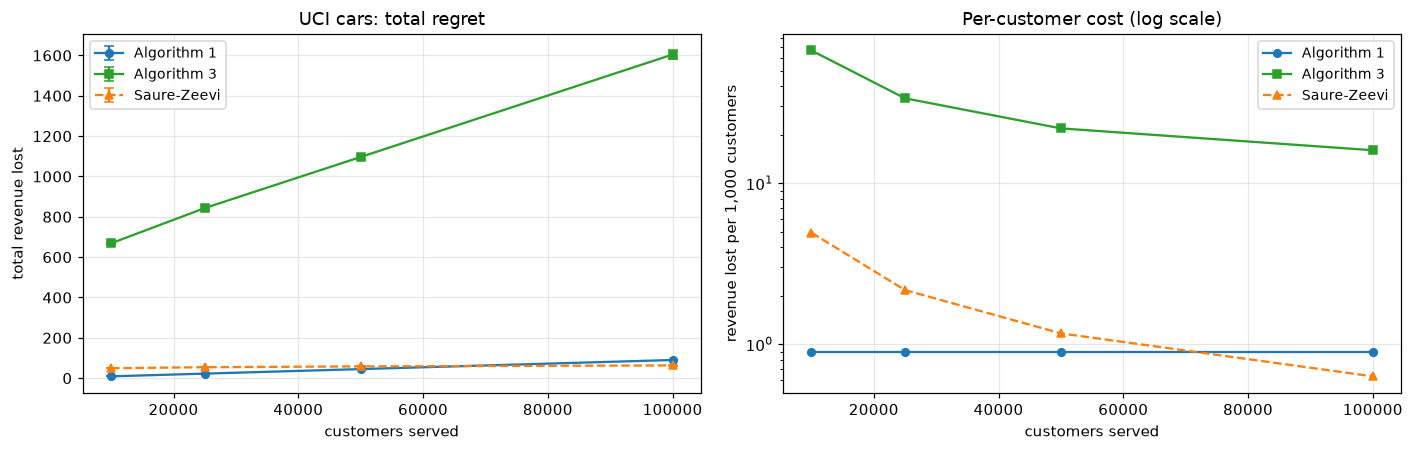

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for a in algo_names:
    rows = exp2["results"][a]
    T = np.array([row["T"] for row in rows], dtype=float)
    mean = np.array([row["mean"] for row in rows], dtype=float)
    err = np.array([row["std_error"] for row in rows], dtype=float)
    axes[0].errorbar(T, mean, yerr=err, fmt=styles[a], color=colours[a],
                     capsize=3, markersize=5, label=a)
    axes[1].plot(T, 1000 * mean / T, styles[a], color=colours[a],
                 markersize=5, label=a)

axes[0].set(xlabel="customers served", ylabel="total revenue lost",
            title="UCI cars: total regret")
axes[1].set(xlabel="customers served",
            ylabel="revenue lost per 1,000 customers",
            title="Per-customer cost (log scale)")
# Log scale, because Algorithm 3's cost is ~70x the others and would otherwise
# flatten them into the axis. On this scale a HORIZONTAL line means the
# algorithm has stopped improving -- which is what Algorithm 1 does here.
axes[1].set_yscale("log")
for ax in axes:
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Reading the car results

The per-customer plot is on a log scale: a horizontal line means the
algorithm has stopped improving. Algorithm 1's is horizontal. The next
cell checks where that constant comes from.


In [15]:
# Why is Algorithm 1's cost exactly 0.8999 per 1,000 customers?
initial_guess = np.ones(len(v_cars))          # what Algorithm 1 starts with
_, first_choice = algorithms.best_assortment(initial_guess, cars["r"], 100)

revenue_of_first_choice = algorithms.expected_revenue(first_choice, v_cars,
                                                      cars["r"])
loss_per_customer = exp2["best_revenue"] - revenue_of_first_choice

chosen = [int(i) for i in first_choice]
print(f"  with every guess equal to 1, it picks {len(chosen)} cars: "
      f"{chosen[:3]} ... {chosen[-1]}")
print(f"  revenue of that set     : {revenue_of_first_choice:.7f}")
print(f"  best possible revenue   : {exp2['best_revenue']:.7f}")
print(f"  loss per customer       : {loss_per_customer:.7f}")
print(f"  loss per 1,000 customers: {1000 * loss_per_customer:.4f}")
print()
measured = [1000 * row["mean"] / row["T"] for row in exp2["results"]["Algorithm 1"]]
print(f"  measured in the experiment: {[round(m, 4) for m in measured]}")
print()
print("  They match. Algorithm 1 never moved off its opening choice, because")
print("  ~11 epochs is not enough to learn anything about 1728 products.")

  with every guess equal to 1, it picks 100 cars: [0, 1, 2] ... 1727
  revenue of that set     : 0.9989944
  best possible revenue   : 0.9998943
  loss per customer       : 0.0008999
  loss per 1,000 customers: 0.8999

  measured in the experiment: [0.8999, 0.8999, 0.8999, 0.8999]

  They match. Algorithm 1 never moved off its opening choice, because
  ~11 epochs is not enough to learn anything about 1728 products.


In [16]:
# Growth of each algorithm's per-customer cost across the tested horizons.
print("cost per 1,000 customers, first horizon -> last")
print("=" * 58)
for name in algo_names:
    rows = exp2["results"][name]
    first = 1000 * rows[0]["mean"] / rows[0]["T"]
    last = 1000 * rows[-1]["mean"] / rows[-1]["T"]
    trend = "flat" if abs(last - first) < 0.01 else f"{first / last:.1f}x lower"
    print(f"  {name:12s} {first:8.4f} -> {last:8.4f}   ({trend})")

# How many estimate updates (epochs) each horizon actually allows.
print()
print(f"epoch length on this instance: {epoch_length:,.0f} customers")
print(f"updates available at T={rows[-1]['T']:,}: "
      f"{rows[-1]['T'] / epoch_length:.0f}")
print(f"updates available at T=10,000,000 (paper): "
      f"{10_000_000 / epoch_length:.0f}")

# How often Saure-Zeevi's estimator is undefined here.
sz_runs = [algorithms.saure_zeevi(v_cars, cars["r"], 100, 100_000, seed=s)
           for s in range(3)]
n_groups = int(np.ceil(len(v_cars) / 100))
print()
print(f"Saure-Zeevi estimation groups with zero no-purchases "
      f"(estimate undefined):")
for k, run in enumerate(sz_runs):
    print(f"  run {k}: {run['degenerate_groups']} of {n_groups} groups")

cost per 1,000 customers, first horizon -> last
  Algorithm 1    0.8999 ->   0.8999   (flat)
  Algorithm 3   66.8632 ->  16.0437   (4.2x lower)
  Saure-Zeevi    4.9336 ->   0.6314   (7.8x lower)

epoch length on this instance: 9,463 customers
updates available at T=100,000: 11
updates available at T=10,000,000 (paper): 1057



Saure-Zeevi estimation groups with zero no-purchases (estimate undefined):
  run 0: 8 of 18 groups
  run 1: 10 of 18 groups
  run 2: 7 of 18 groups


Algorithm 1's cost does not move over this range: with ~11 epochs it never
leaves its opening assortment. The paper's horizon gives ~1,057 epochs.

The paper (§7.3, Figure 4) reports Sauré–Zeevi's regret growing linearly on
this dataset while Algorithm 1's does not. **That is not reproduced here.**

Sauré–Zeevi's estimator divides by the number of customers who bought
nothing, which is zero for about half the groups on this instance.


---

## 6. Run it yourself

Everything above used precomputed results. This section runs the actual
algorithms **live**, on a smaller problem, so you can verify the code works.
It takes about two minutes.

In [17]:
# A smaller version of experiment 1: shorter horizon, fewer repeats.
EPSILON = 0.10
HORIZON = 10_000
N_RUNS = 3

v_demo, r_demo, K_demo = algorithms.synthetic_instance(EPSILON)
best_value, best_set = algorithms.best_assortment(v_demo, r_demo, K_demo)

print(f"Synthetic problem, epsilon = {EPSILON}")
print(f"  best set = products {tuple(int(i) + 1 for i in best_set)}, "
      f"revenue {best_value:.4f}")
print(f"  running {HORIZON:,} customers x {N_RUNS} repeats per algorithm\n")

live = {}
for name, algo in [("Algorithm 1", algorithms.algorithm_1),
                   ("Algorithm 3", algorithms.algorithm_3),
                   ("Saure-Zeevi", algorithms.saure_zeevi)]:
    regrets = [algo(v_demo, r_demo, K_demo, HORIZON, seed=s)["regret"]
               for s in range(N_RUNS)]
    live[name] = float(np.mean(regrets))
    print(f"  {name:12s} regret = {np.mean(regrets):7.1f}"
          f"   (runs: {', '.join(f'{x:.0f}' for x in regrets)})")

print("\nCompare against the saved full-scale results at the same horizon:")
for name in algo_names:
    match = [row for row in saved["experiment_1"][str(EPSILON)]["results"][name]
             if row["T"] == HORIZON]
    if match:
        print(f"  {name:12s} saved = {match[0]['mean']:7.1f}"
              f"   live = {live[name]:7.1f}")

Synthetic problem, epsilon = 0.1
  best set = products (1, 2, 9, 10), revenue 0.5833
  running 10,000 customers x 3 repeats per algorithm



  Algorithm 1  regret =   355.6   (runs: 353, 354, 359)


  Algorithm 3  regret =   406.8   (runs: 405, 415, 400)
  Saure-Zeevi  regret =   287.5   (runs: 225, 225, 412)

Compare against the saved full-scale results at the same horizon:
  Algorithm 1  saved =   352.4   live =   355.6
  Algorithm 3  saved =   423.5   live =   406.8
  Saure-Zeevi  saved =   211.3   live =   287.5


In [18]:
# Watch a single epoch happen, step by step.
rng = np.random.default_rng(1)
S = best_set

print(f"Showing products {tuple(int(i) + 1 for i in S)} until someone buys nothing:\n")
for customer in range(1, 40):
    bought = algorithms.simulate_one_customer(S, v_demo, rng)
    if bought is None:
        print(f"  customer {customer}: bought NOTHING  -> epoch ends")
        break
    print(f"  customer {customer}: bought product {int(bought) + 1}")

print("\nThe algorithm now counts the purchases above and updates its estimates.")
print("That count, averaged over many epochs, converges to the true v.")

Showing products (1, 2, 9, 10) until someone buys nothing:

  customer 1: bought product 10
  customer 2: bought NOTHING  -> epoch ends

The algorithm now counts the purchases above and updates its estimates.
That count, averaged over many epochs, converges to the true v.


---

## 7. Summary

**Experiment 1 (synthetic).** Algorithm 1 and Algorithm 3 have similar regret at
all four gaps. Sauré–Zeevi's mean regret falls sharply as the gap widens, from
1764 at $\varepsilon=0.05$ to 92 at $\varepsilon=0.25$, but its spread across
runs is large at small gaps: at $\varepsilon=0.05$ it identified the optimal
assortment in 1 of 20 runs, with regret between 55 and 2204.

**Experiment 2 (UCI cars).** Algorithm 1's regret per customer is constant at
0.8999 per 1,000 across all horizons tested, matching the gap of its initial
assortment. Algorithm 3's regret is highest (1604 at $T=10^5$). Sauré–Zeevi's
per-customer cost falls from 4.93 to 0.63 per 1,000.

**Not reproduced.** Paper §7.3 reports Sauré–Zeevi incurring linear regret on the
car data while Algorithm 1 does not. This run does not show that.

**Differences from the paper's setup.** Horizons $10^5$ against $10^6$–$10^7$;
10 runs against 100; the car instance's $v$ is fitted from quality ratings, not
observed purchases (§4).

**Files.** `code/algorithms.py`, `code/run_experiments.py`,
`results/experiment_results.json`, `data/car.data`.